In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
data = np.load('X_data.npy')  # shape: (T, lookback, 2 * n_assets)
returns = np.load('Y_data.npy')  # shape: (T, n_assets)
assert data.shape[0] == returns.shape[0]

In [3]:
n_assets = returns.shape[1]
lookback = data.shape[1]

In [4]:
class SharpeModel(tf.keras.Model):
    def __init__(self, n_assets):
        super().__init__()
        self.lstm = tf.keras.layers.LSTM(64)
        self.dense = tf.keras.layers.Dense(n_assets)

    def call(self, x):
        x = self.lstm(x)
        raw_weights = self.dense(x)
        weights = tf.nn.softmax(raw_weights)
        return weights

In [5]:
def sharpe_loss(R, W):
    R = tf.cast(R, tf.float32)
    W = tf.cast(W, tf.float32)
    portfolio_returns = tf.reduce_sum(R * W, axis=1)
    mean = tf.reduce_mean(portfolio_returns)
    std = tf.math.reduce_std(portfolio_returns)
    sharpe = mean / (std + 1e-8)
    return -sharpe

In [6]:
def exponential_weighted_volatility(returns, span=50):
    alpha = 2 / (span + 1)
    ewma = [returns[0]]
    for r in returns[1:]:
        ewma.append(alpha * r + (1 - alpha) * ewma[-1])
    ewma = np.array(ewma)
    squared_diff = (returns - ewma) ** 2
    ew_var = np.convolve(squared_diff, np.exp(-np.arange(span)[::-1] * alpha), mode='valid')
    ew_std = np.sqrt(ew_var)
    return np.pad(ew_std, (span - 1, 0), constant_values=np.nan)

In [7]:
def train_model_sharpe(X, R, epochs=100):
    model = SharpeModel(n_assets)
    optimizer = tf.keras.optimizers.Adam(1e-3)
    val_split = int(0.9 * len(X))
    X_train, R_train = X[:val_split], R[:val_split]
    X_val, R_val = X[val_split:], R[val_split:]
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, R_train)).batch(64)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, R_val)).batch(64)

    for epoch in range(epochs):
        for x_batch, r_batch in train_dataset:
            with tf.GradientTape() as tape:
                weights = model(x_batch)
                loss = sharpe_loss(r_batch, weights)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        val_losses = [sharpe_loss(r, model(x)).numpy() for x, r in val_dataset]
        print(f"Epoch {epoch+1}/{epochs} - Validation Sharpe Loss: {-np.mean(val_losses):.4f}")

    return model

In [8]:
def backtest(X, R, model, cost_rate=0.0001, vol_target=0.10):
    T = len(X)
    returns = []
    weights = []
    prev_scaled = np.zeros(R.shape[1])
    vol_est = np.array([exponential_weighted_volatility(R[:, i]) for i in range(R.shape[1])]).T
    
    for t in range(2, T):
        sigma = vol_est[t - 1]
        if np.any(np.isnan(sigma)):
            returns.append(0)
            continue
        w_prev = model(X[t - 1:t]).numpy().flatten()
        scaled = (vol_target / sigma) * w_prev
        rp = np.dot(scaled, R[t])
        cost = cost_rate * np.sum(np.abs(scaled - prev_scaled))
        net_return = rp - cost
        returns.append(net_return)
        prev_scaled = scaled
        weights.append(w_prev)

    return np.array(returns), np.array(weights)

In [9]:
def evaluate_performance(returns, trading_days=252):
    mean = np.mean(returns)
    std = np.std(returns)
    sharpe = mean / (std + 1e-8) * np.sqrt(trading_days)
    downside = returns[returns < 0]
    dd_std = np.std(downside) if len(downside) > 0 else 0
    sortino = mean / (dd_std + 1e-8) * np.sqrt(trading_days)
    cum_returns = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(cum_returns)
    drawdowns = (cum_returns - peak) / peak
    max_dd = np.min(drawdowns)
    pct_pos = np.sum(returns > 0) / len(returns)
    avg_gain = np.mean(returns[returns > 0]) if np.any(returns > 0) else 0
    avg_loss = -np.mean(returns[returns < 0]) if np.any(returns < 0) else 1e-8
    pl_ratio = avg_gain / avg_loss if avg_loss > 0 else 0

    return {
        "Annualized Return (E[R])": mean * trading_days,
        "Annualized Std Dev (Std[R])": std * np.sqrt(trading_days),
        "Sharpe Ratio": sharpe,
        "Downside Deviation": dd_std * np.sqrt(trading_days),
        "Sortino Ratio": sortino,
        "Max Drawdown (MDD)": max_dd,
        "% Positive Returns": pct_pos,
        "Avg P / Avg L": pl_ratio,
        "Cumulative Returns": cum_returns
    }

In [12]:
all_model_returns = []
start_index = 0
start_year = 2006
samples_per_year = 252
train_start = 0
train_end = (2011 - start_year) * samples_per_year
end_index = len(data)
window = 2 * samples_per_year
return_dates = []



Training on samples 0 to 1259
Epoch 1/100 - Validation Sharpe Loss: 0.0765
Epoch 2/100 - Validation Sharpe Loss: 0.1202
Epoch 3/100 - Validation Sharpe Loss: 0.1845
Epoch 4/100 - Validation Sharpe Loss: 0.1922
Epoch 5/100 - Validation Sharpe Loss: 0.1770
Epoch 6/100 - Validation Sharpe Loss: 0.1832
Epoch 7/100 - Validation Sharpe Loss: 0.1497
Epoch 8/100 - Validation Sharpe Loss: 0.1463
Epoch 9/100 - Validation Sharpe Loss: 0.1718
Epoch 10/100 - Validation Sharpe Loss: 0.1369
Epoch 11/100 - Validation Sharpe Loss: 0.1545
Epoch 12/100 - Validation Sharpe Loss: 0.1733
Epoch 13/100 - Validation Sharpe Loss: 0.1995
Epoch 14/100 - Validation Sharpe Loss: 0.1820
Epoch 15/100 - Validation Sharpe Loss: 0.2027
Epoch 16/100 - Validation Sharpe Loss: 0.1726
Epoch 17/100 - Validation Sharpe Loss: 0.2095
Epoch 18/100 - Validation Sharpe Loss: 0.1405
Epoch 19/100 - Validation Sharpe Loss: 0.2104
Epoch 20/100 - Validation Sharpe Loss: 0.1623
Epoch 21/100 - Validation Sharpe Loss: 0.2073
Epoch 22/100

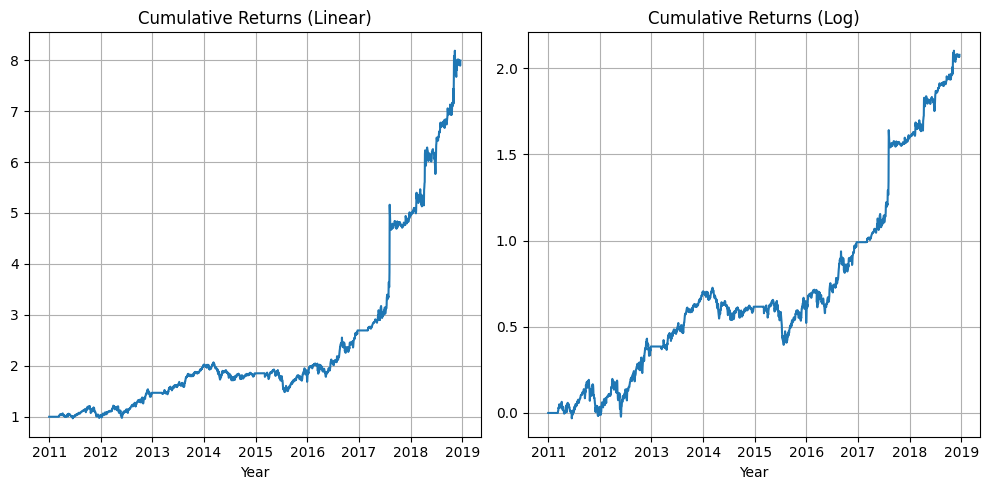

In [13]:
while train_end + window <= end_index:
    print(f"\nTraining on samples {train_start} to {train_end - 1}")
    model = train_model_sharpe(data[:train_end], returns[:train_end])
    X_test = data[train_end:train_end + window]
    R_test = returns[train_end:train_end + window]
    test_returns = backtest(X_test, R_test, model)
    all_model_returns.append(test_returns)
    return_dates.extend(range(train_end, train_end + len(test_returns[0])))
    train_end += window

model_returns = np.concatenate([r for r, _ in all_model_returns])
model_metrics = evaluate_performance(model_returns)

# Convert index to actual years
start_test_year = 2011
dates = np.array([start_test_year + i / samples_per_year for i in range(len(model_returns))])

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(dates, model_metrics["Cumulative Returns"], label="DLS")
plt.title("Cumulative Returns (Linear)")
plt.xlabel("Year")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(dates, np.log(model_metrics["Cumulative Returns"]), label="DLS")
plt.title("Cumulative Returns (Log)")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
print("\nModel Performance Metrics (DLS):")
for k, v in model_metrics.items():
    if k != "Cumulative Returns":
        print(f"{k}: {v:.4f}")


Model Performance Metrics (DLS):
Annualized Return (E[R]): 0.2892
Annualized Std Dev (Std[R]): 0.2438
Sharpe Ratio: 1.1865
Downside Deviation: 0.1508
Sortino Ratio: 1.9182
Max Drawdown (MDD): -0.2822
% Positive Returns: 0.4801
Avg P / Avg L: 1.1408
